In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import warnings
warnings.filterwarnings('ignore')


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

# Read Excel file
data = pd.read_csv('/content/drive/MyDrive/Ovarian cancer Project/Dataset/ovariantotal.csv')

# Show first few rows
print(data.head())


     AFP     AG  Age   ALB  ALP  ALT  AST  BASO#  BASO%   BUN  ...   PCT  \
0   3.58  19.36   47  45.4   56   11   24   0.01   0.30  5.35  ...  0.09   
1  34.24  23.98   61  39.9   95    9   13   0.02   0.30  3.21  ...  0.30   
2   1.50  18.40   39  45.4   77    9   18   0.03   0.60  3.80  ...  0.13   
3   2.75  16.60   45  39.2   26   16   17   0.05   0.74  5.27  ...  0.25   
4   2.36  19.97   45  35.0   47   21   27   0.01   0.10  4.89  ...  0.28   

    PDW  PHOS  PLT   RBC   RDW  TBIL    TP     UA  TYPE  
0  13.4  1.46   74  2.64  13.7   5.5  73.9  396.4     0  
1  11.2  1.09  304  4.89  12.7   6.8  72.0  119.2     0  
2  15.2  0.97  112  4.62  12.0  14.8  77.9  209.2     0  
3  17.4  1.25  339  4.01  14.6  10.9  66.1  215.6     0  
4  11.9  0.94  272  4.40  13.4   5.3  66.5  206.0     0  

[5 rows x 50 columns]


In [ ]:
data.shape

(349, 50)

In [ ]:
# Shape and types
print("Shape:", data.shape)
print("\nData types:\n", data.dtypes)

Shape: (349, 50)

Data types:
 AFP          float64
AG           float64
Age            int64
ALB          float64
ALP            int64
ALT            int64
AST            int64
BASO#        float64
BASO%        float64
BUN          float64
Ca           float64
CA125        float64
CA19-9       float64
CA72-4       float64
CEA          float64
CL           float64
CO2CP        float64
CREA         float64
DBIL         float64
EO#          float64
EO%          float64
GGT            int64
GLO          float64
GLU.         float64
HCT          float64
HE4          float64
HGB          float64
IBIL         float64
K            float64
LYM#         float64
LYM%         float64
MCH          float64
MCV          float64
Menopause      int64
Mg           float64
MONO#        float64
MONO%        float64
MPV          float64
Na           float64
NEU          float64
PCT          float64
PDW          float64
PHOS         float64
PLT            int64
RBC          float64
RDW          float64
TBI

In [ ]:
import pandas as pd

# Check for blank strings ("" or " ")
blank_counts = (data == ' ').sum() + (data == '').sum()
print("Blank string counts:\n", blank_counts)

Blank string counts:
 AFP          0
AG           0
Age          0
ALB          0
ALP          0
ALT          0
AST          0
BASO#        0
BASO%        0
BUN          0
Ca           0
CA125        0
CA19-9       0
CA72-4       0
CEA          0
CL           0
CO2CP        0
CREA         0
DBIL         0
EO#          0
EO%          0
GGT          0
GLO          0
GLU.         0
HCT          0
HE4          0
HGB          0
IBIL         0
K            0
LYM#         0
LYM%         0
MCH          0
MCV          0
Menopause    0
Mg           0
MONO#        0
MONO%        0
MPV          0
Na           0
NEU          0
PCT          0
PDW          0
PHOS         0
PLT          0
RBC          0
RDW          0
TBIL         0
TP           0
UA           0
TYPE         0
dtype: int64


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

# Drop the 'TYPE' column for outlier detection
numerical_data = data.drop(columns=['TYPE'])
# Define a list of Z-score thresholds to loop through
z_score_thresholds = [1, 1.5, 2, 2.5, 3]

# Create a dictionary to store the results
outlier_analysis = {}

# Loop through each threshold value
for threshold in z_score_thresholds:
    outlier_indices = set()
    for column in numerical_data.columns:
        z_scores = np.abs(stats.zscore(numerical_data[column]))
        outliers = np.where(z_scores > threshold)[0]
        outlier_indices.update(outliers)

    num_outlier_rows = len(outlier_indices)
    percentage_outliers = (num_outlier_rows / len(data)) * 100

    outlier_analysis[f"Z-score > {threshold}"] = {
        'Number of Outlier Rows': num_outlier_rows,
        'Percentage of Outlier Rows': percentage_outliers
    }

# Convert the results to a DataFrame for a clean output
results_data = pd.DataFrame(outlier_analysis).T

# Print the final results table
print("Outlier Analysis with Different Z-score Thresholds:")
print(results_data.to_markdown(numalign="left", stralign="left"))

Outlier Analysis with Different Z-score Thresholds:
|               | Number of Outlier Rows   | Percentage of Outlier Rows   |
|:--------------|:-------------------------|:-----------------------------|
| Z-score > 1   | 349                      | 100                          |
| Z-score > 1.5 | 317                      | 90.8309                      |
| Z-score > 2   | 222                      | 63.6103                      |
| Z-score > 2.5 | 141                      | 40.4011                      |
| Z-score > 3   | 101                      | 28.9398                      |


| Group              | Method Used     | Why?                                                                                        |
| ------------------ | --------------- | ------------------------------------------------------------------------------------------- |
| Tumor markers      | Log transform   | These features (e.g., CA125, AFP, CA19-9) are usually right-skewed, so log helps normalize. |
| Blood chemistry    | IQR capping     | These are continuous lab values, better to cap extremes using quartiles.                    |
| CBC (blood counts) | Z-score capping | Blood counts are closer to normal distribution, so Z-score fits.                            |
| Others             | No change       | Age, Menopause, TYPE are categorical/ordinal, so outlier logic doesn’t apply.               |


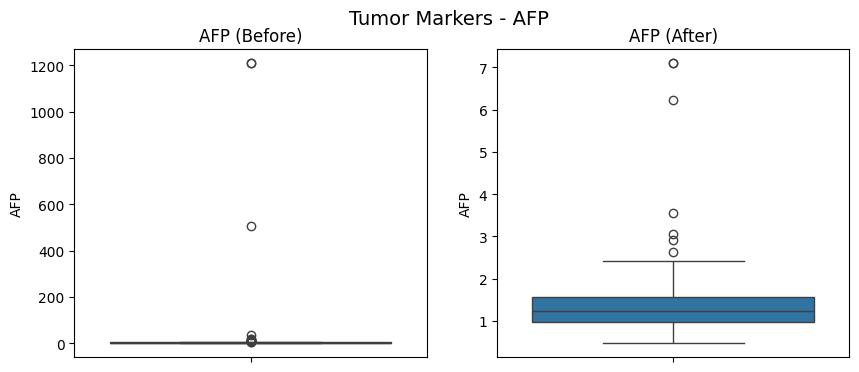

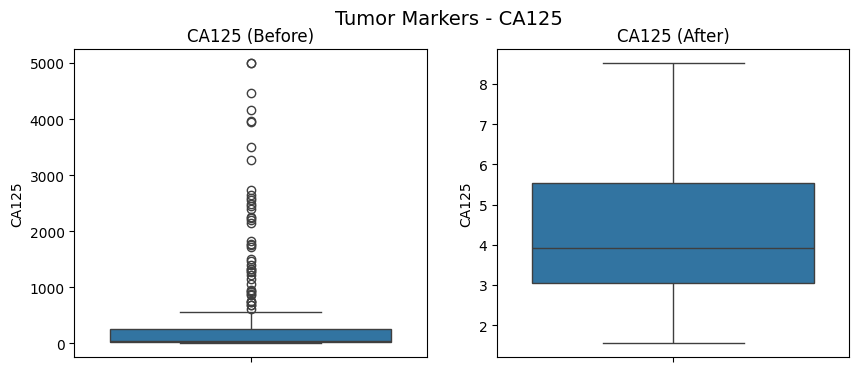

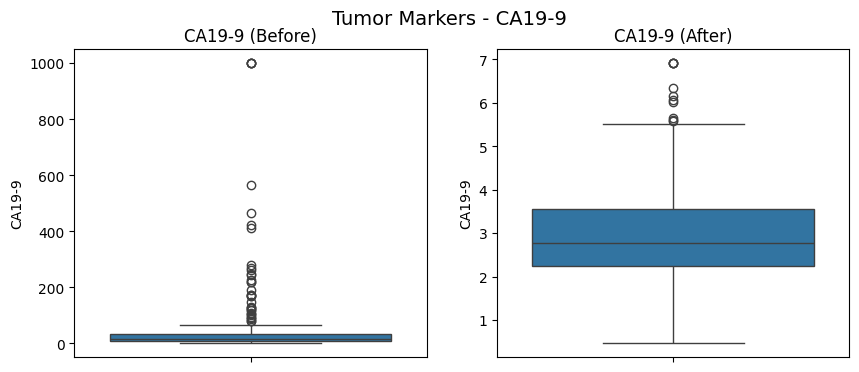

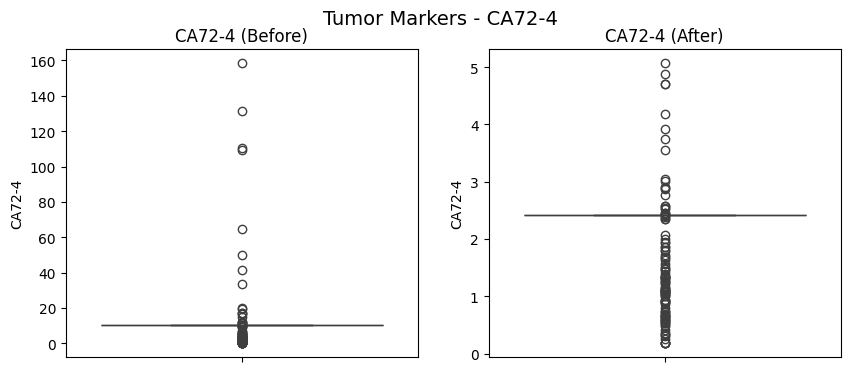

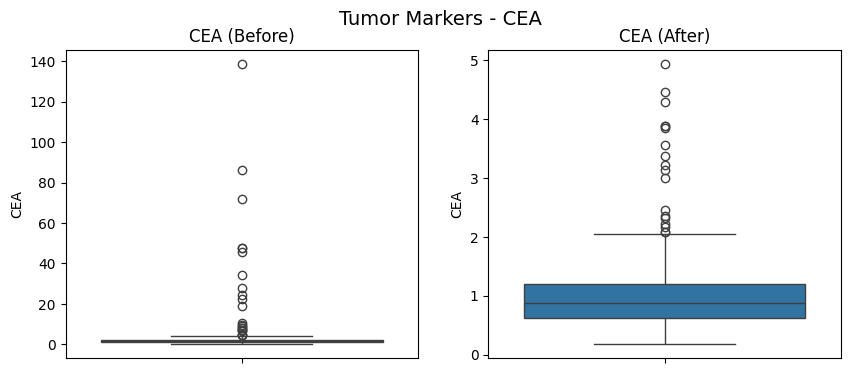

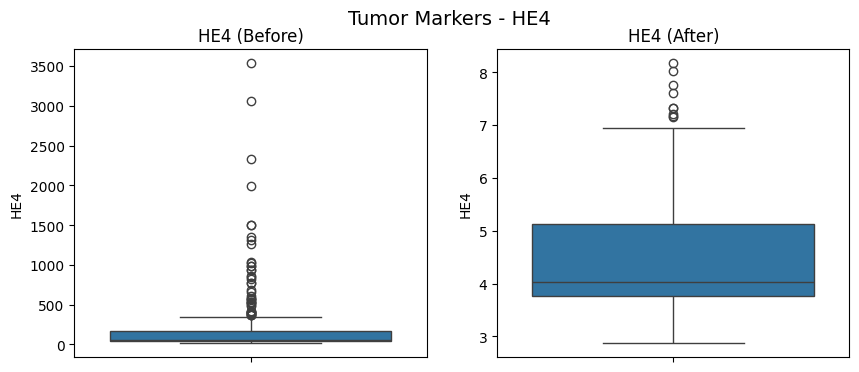

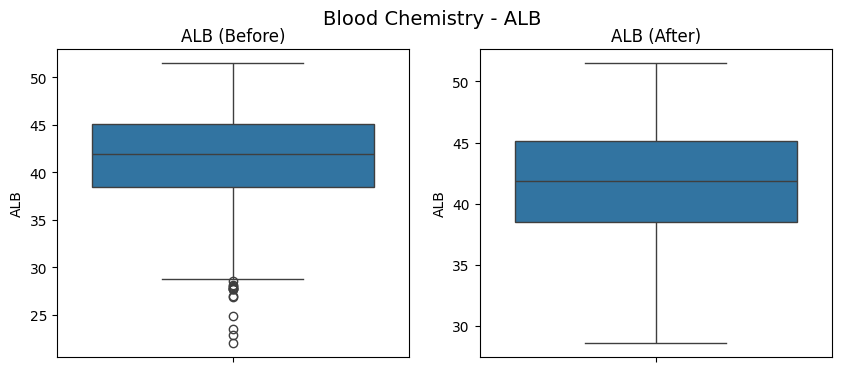

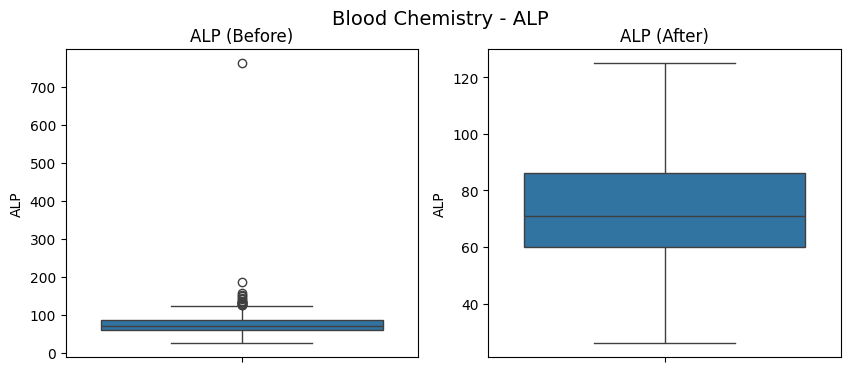

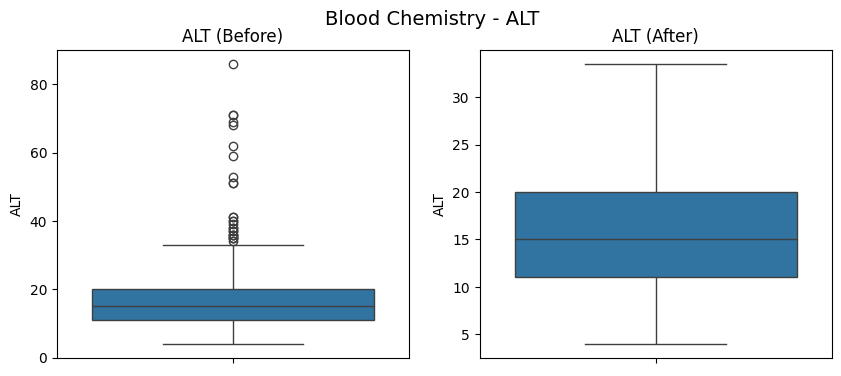

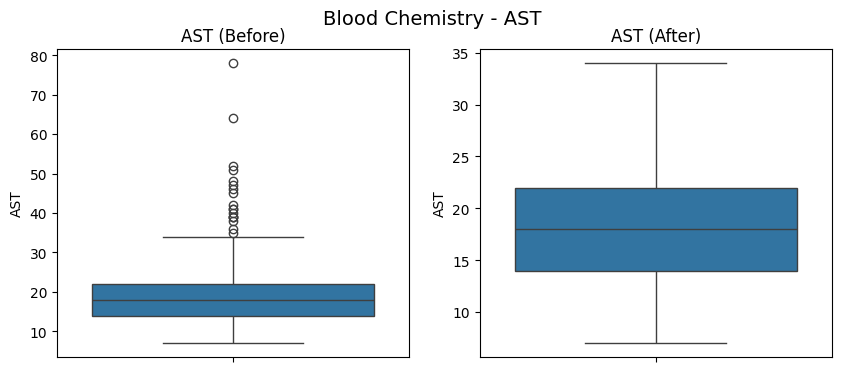

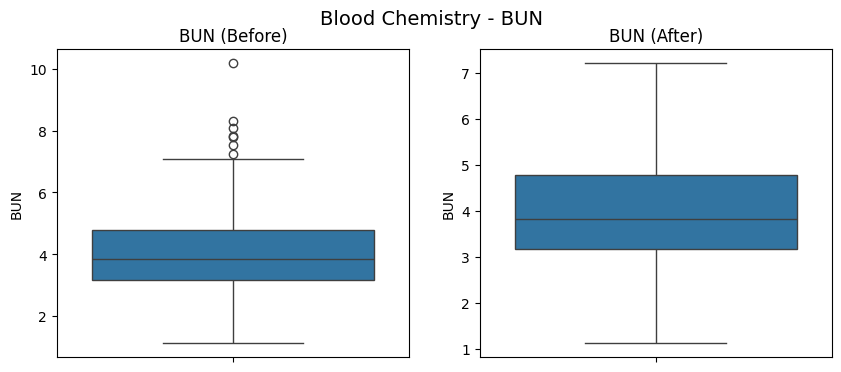

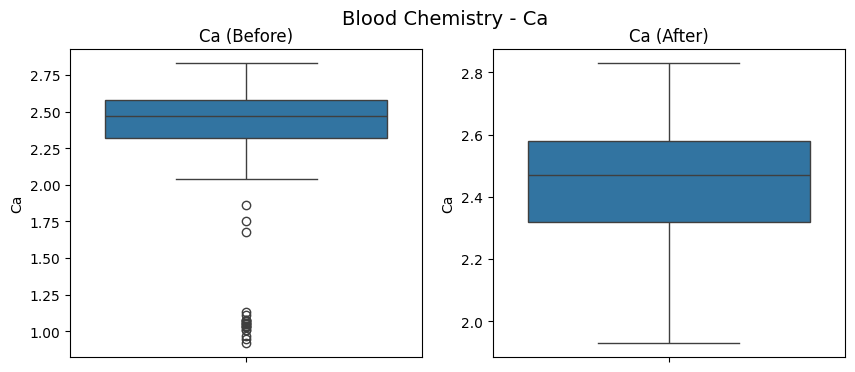

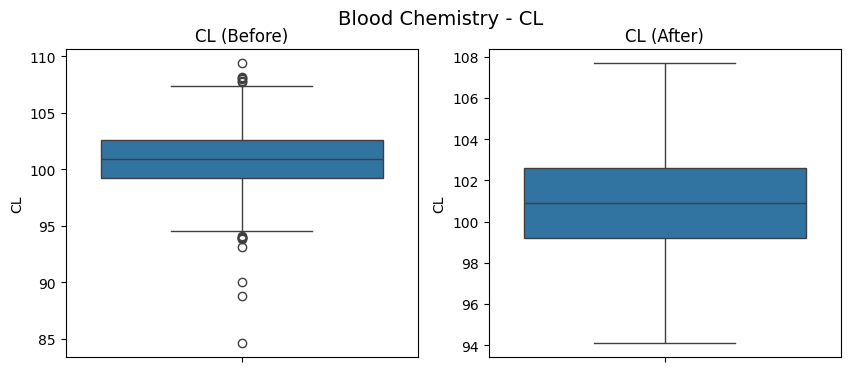

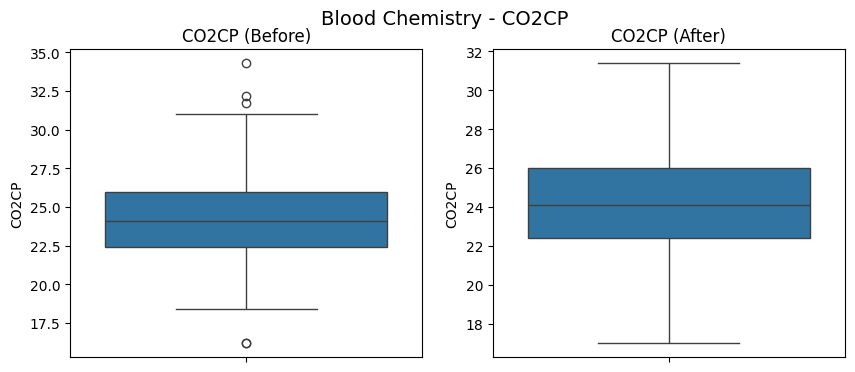

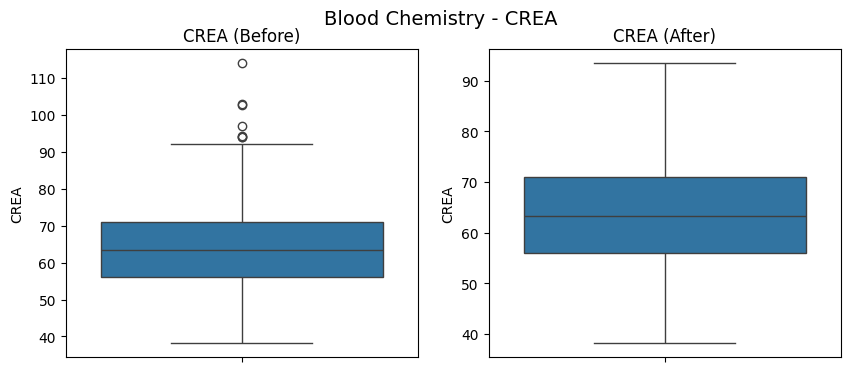

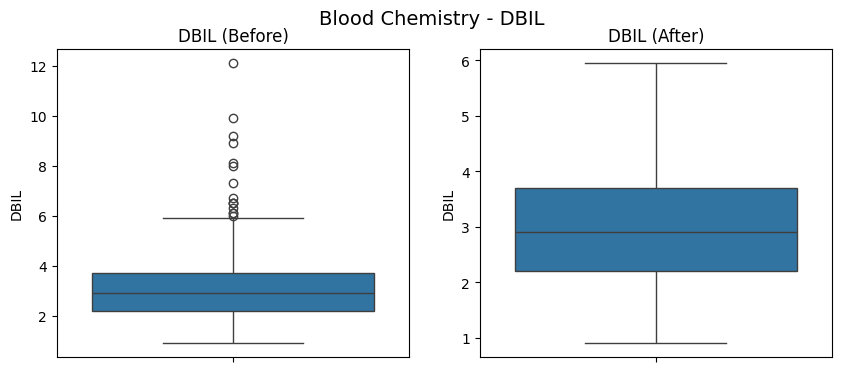

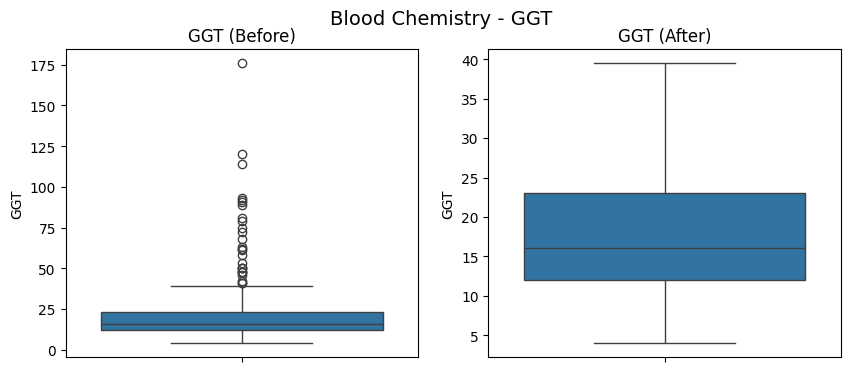

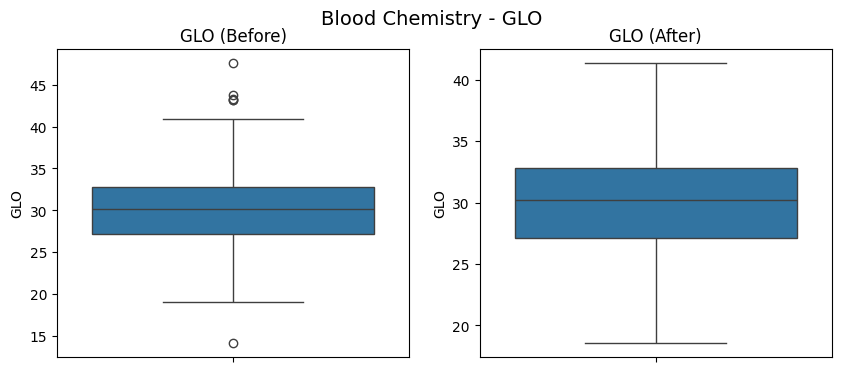

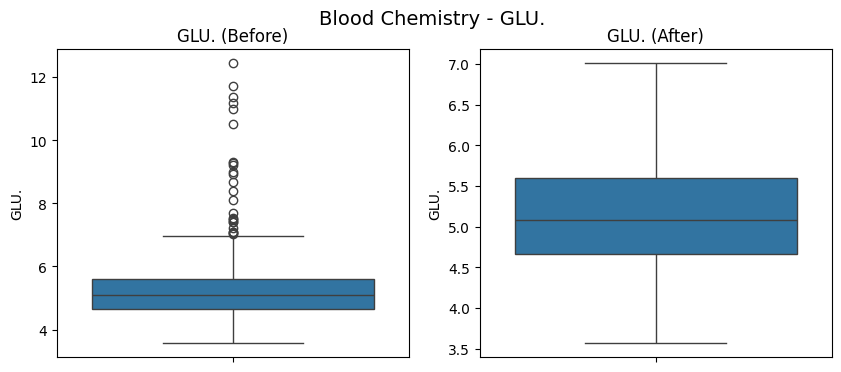

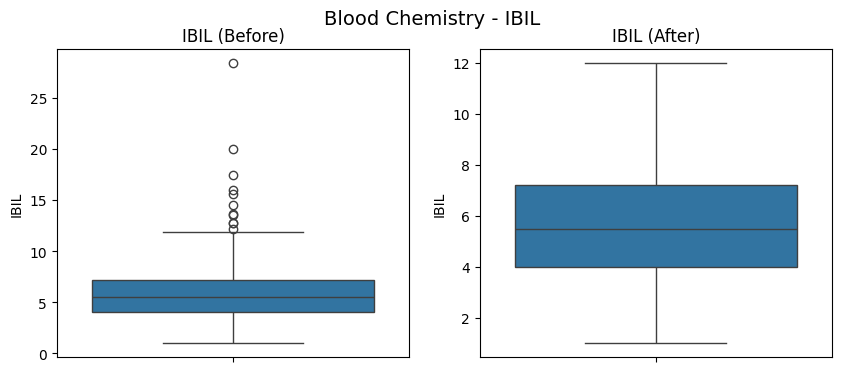

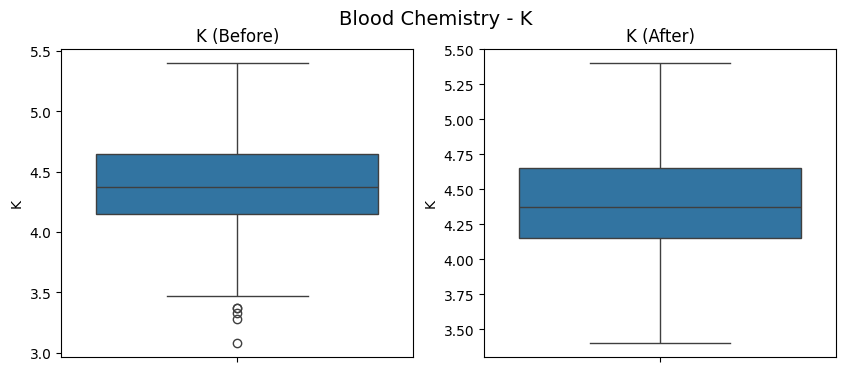

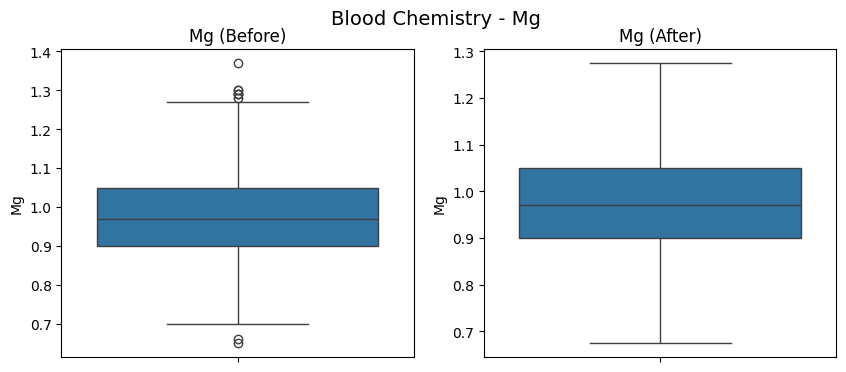

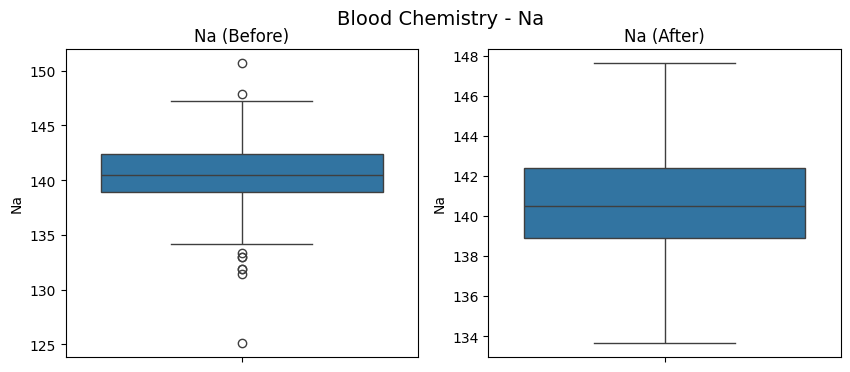

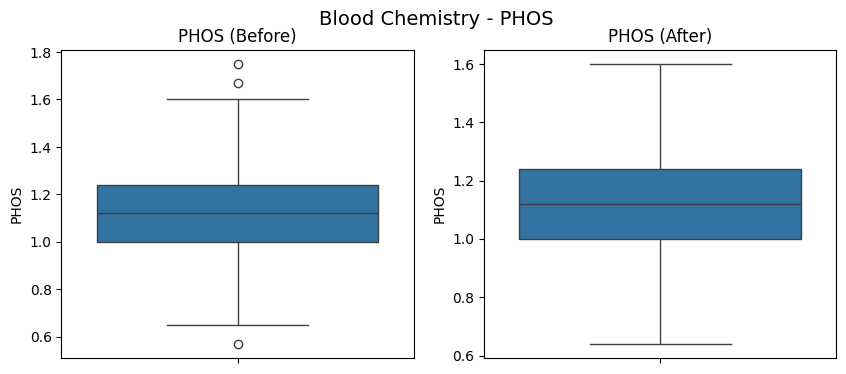

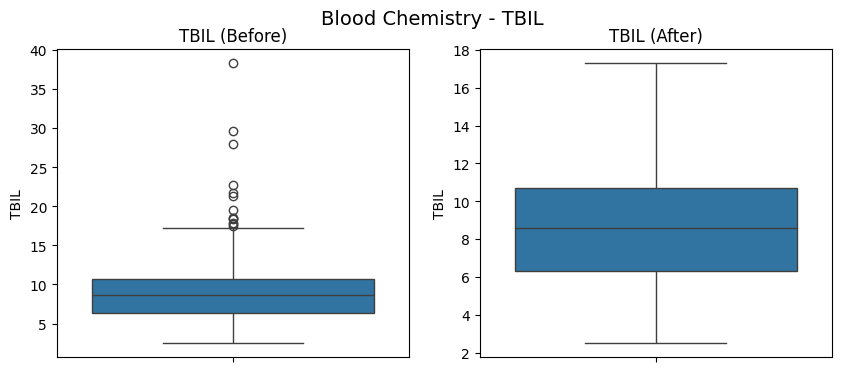

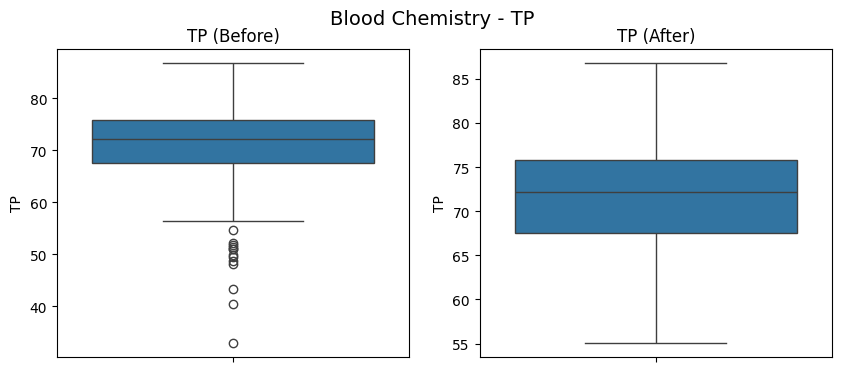

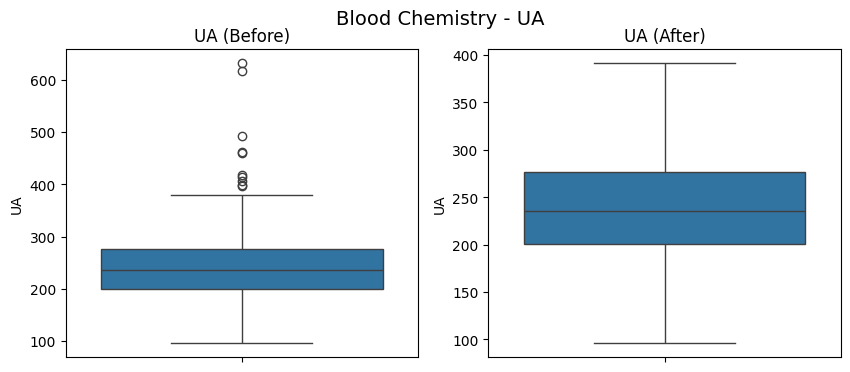

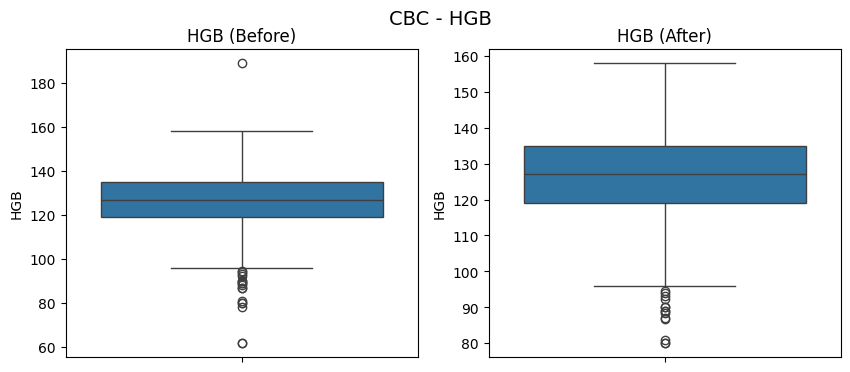

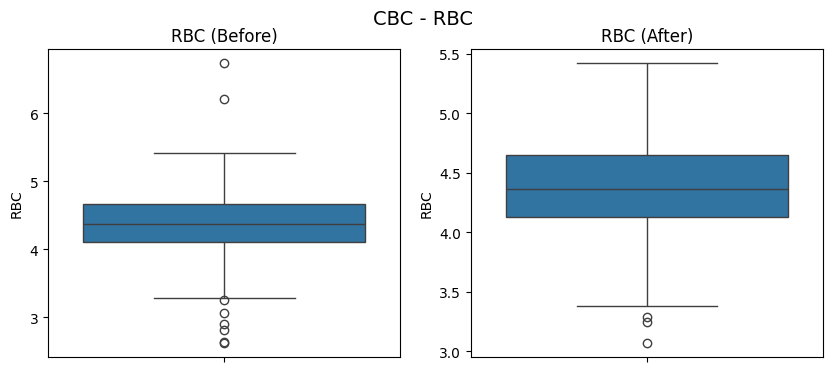

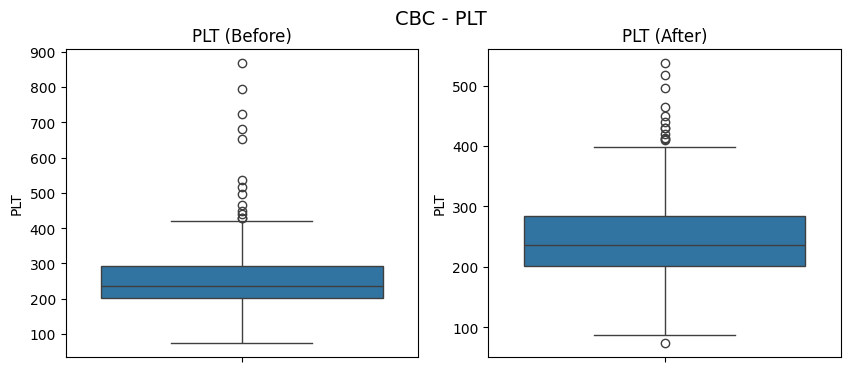

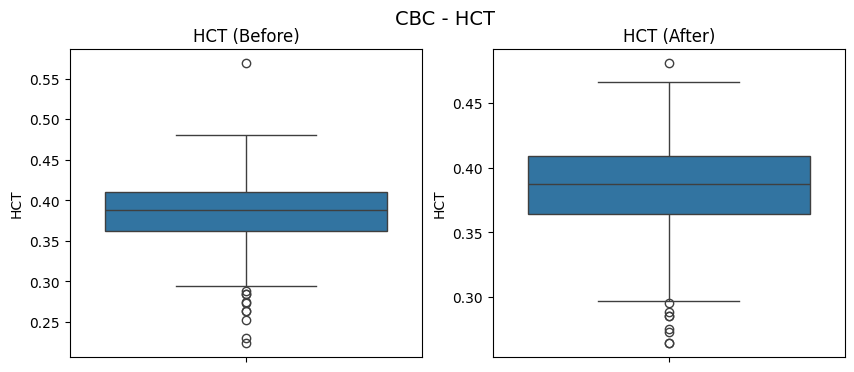

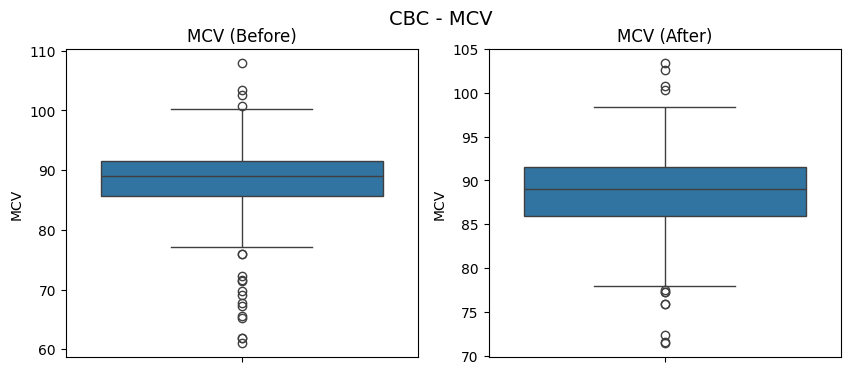

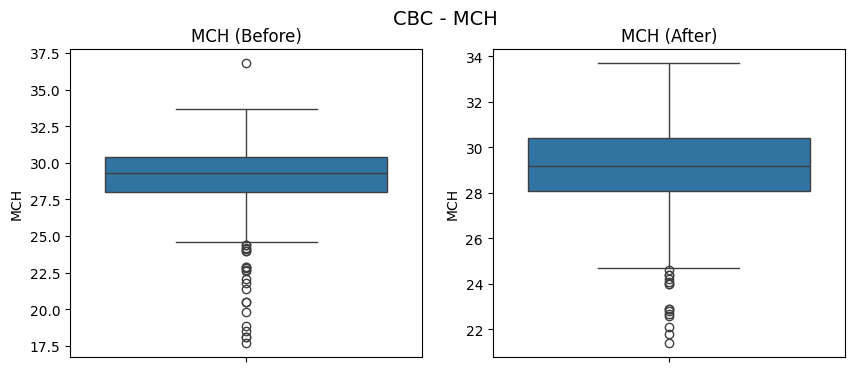

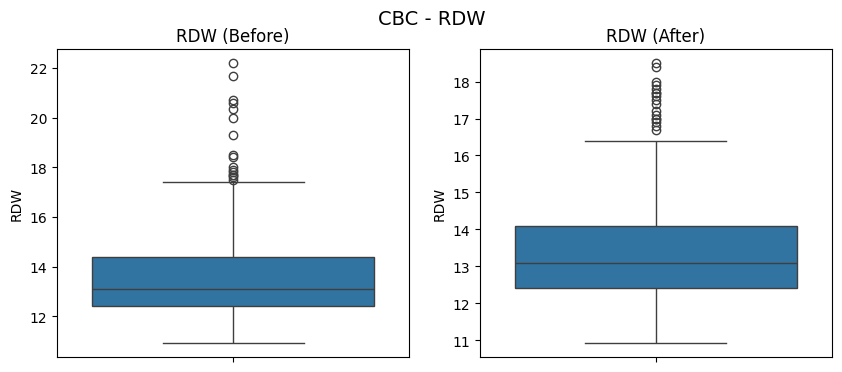

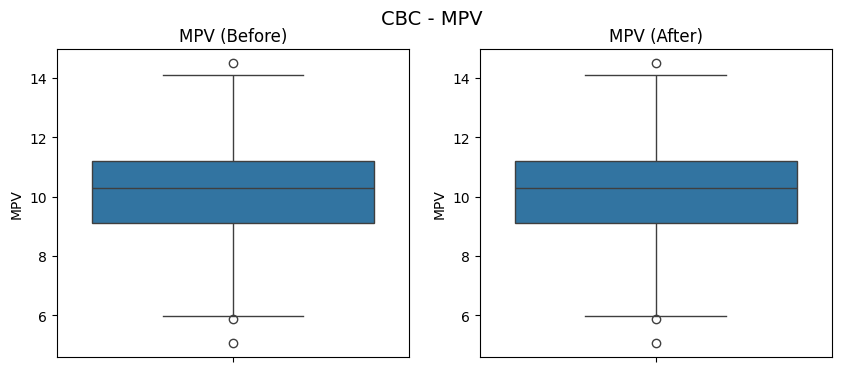

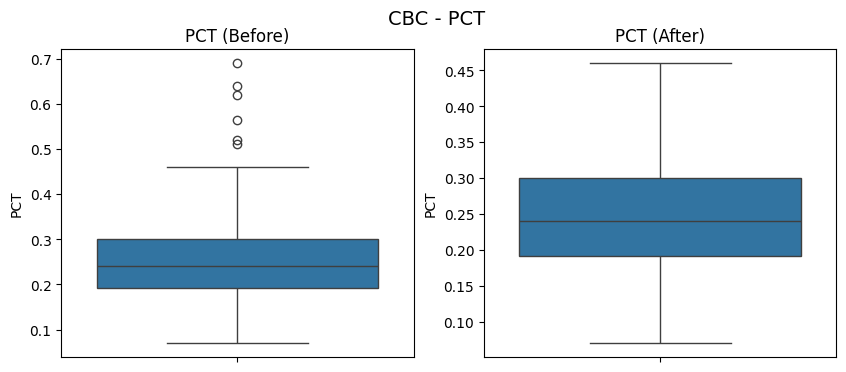

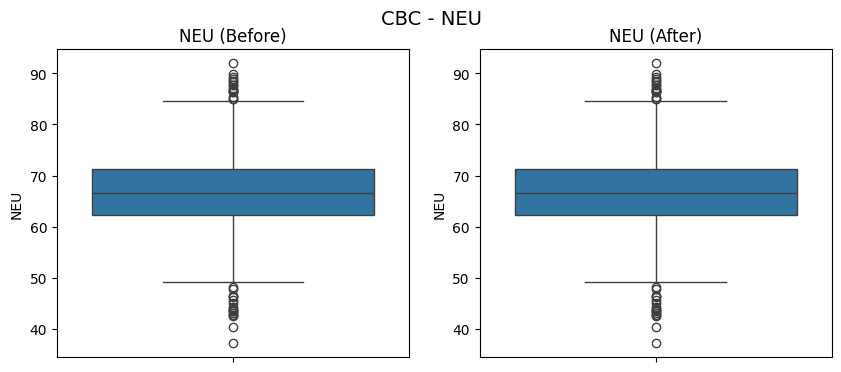

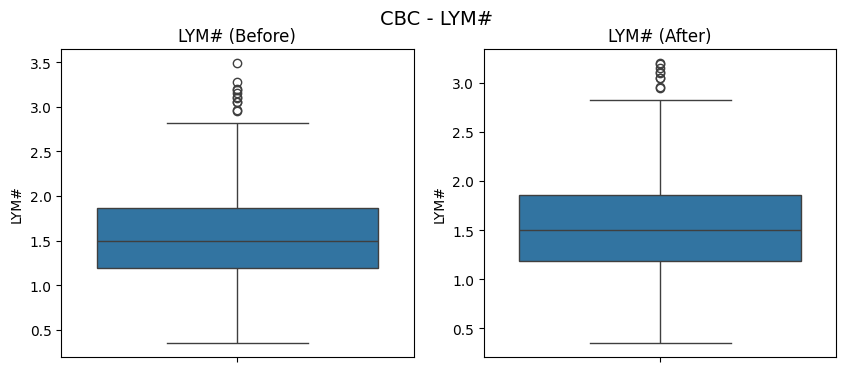

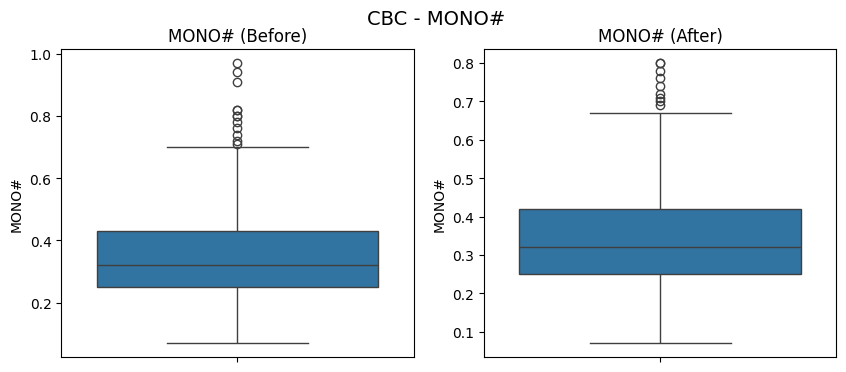

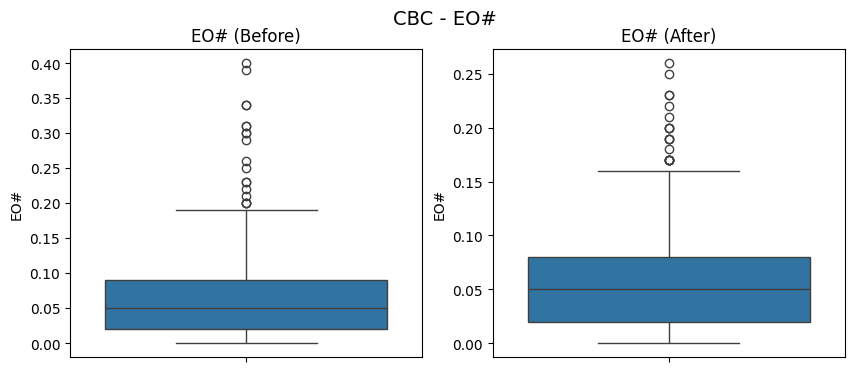

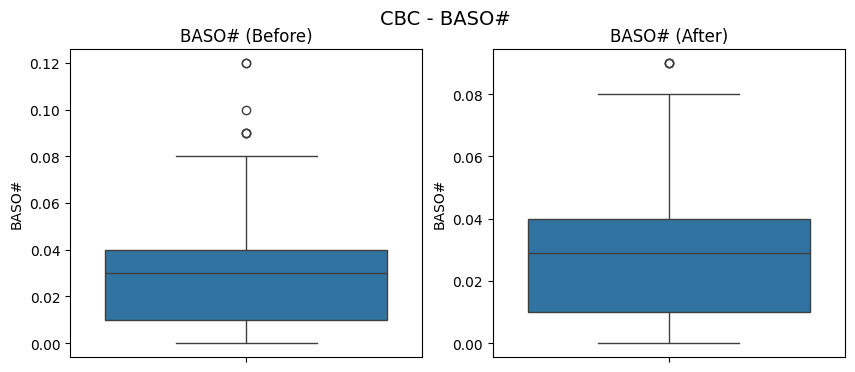

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt

# Example grouping (adjust according to your dataset)
tumor_markers = ["AFP", "CA125", "CA19-9", "CA72-4", "CEA", "HE4"]
blood_chemistry = ["ALB", "ALP", "ALT", "AST", "BUN", "Ca", "CL", "CO2CP", "CREA",
                   "DBIL", "GGT", "GLO", "GLU.", "IBIL", "K", "Mg", "Na", "PHOS",
                   "TBIL", "TP", "UA"]
cbc = ["HGB", "RBC", "WBC", "PLT", "HCT", "MCV", "MCH", "RDW", "MPV", "PCT", "NEU", "LYM#", "MONO#", "EO#", "BASO#"]

# --- Outlier handling strategies ---
def log_transform(df, cols):
    for col in cols:
        if col in df.columns:
            df[col] = np.log1p(df[col])  # log(1+x) to avoid log(0)
    return df

def iqr_capping(df, cols):
    for col in cols:
        if col in df.columns:
            Q1 = df[col].quantile(0.25)
            Q3 = df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            df[col] = np.where(df[col] < lower, lower,
                               np.where(df[col] > upper, upper, df[col]))
    return df

def zscore_capping(df, cols, threshold=3):
    for col in cols:
        if col in df.columns:
            z_scores = np.abs(stats.zscore(df[col].dropna()))
            mask = z_scores > threshold
            mean_val = df[col].mean()
            df.loc[mask, col] = mean_val  # cap extreme values at mean
    return df

# --- Visualization function ---
def visualize_outliers(df_before, df_after, cols, group_name):
    for col in cols:
        if col in df_before.columns:
            fig, axes = plt.subplots(1, 2, figsize=(10, 4))
            sns.boxplot(y=df_before[col], ax=axes[0])
            axes[0].set_title(f"{col} (Before)")
            sns.boxplot(y=df_after[col], ax=axes[1])
            axes[1].set_title(f"{col} (After)")
            fig.suptitle(f"{group_name} - {col}", fontsize=14)
            plt.show()

# --- Apply strategies ---
data_before = data.copy()

# Tumor markers (log transform)
data = log_transform(data, tumor_markers)

# Blood chemistry (IQR capping)
data = iqr_capping(data, blood_chemistry)

# CBC (Z-score capping)
data = zscore_capping(data, cbc)

# --- Visual check ---
visualize_outliers(data_before, data, tumor_markers, "Tumor Markers")
visualize_outliers(data_before, data, blood_chemistry, "Blood Chemistry")
visualize_outliers(data_before, data, cbc, "CBC")


In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import numpy as np
import warnings

warnings.filterwarnings("ignore")

# 1️⃣ Prepare features and target
X = data.drop("TYPE", axis=1)  # Features
y = data["TYPE"]               # Target

# 2️⃣ Define base models
models = {
    "LogisticRegression": LogisticRegression(),
    "RandomForest": RandomForestClassifier(),
    "SVM": SVC(probability=True)  # probability=True needed for ROC later
}

# 3️⃣ Store results for each model
results = {}

for model_name, model in models.items():
    best_score = 0
    best_k = 0
    best_indices = None
    best_feature_names = None

    # Try different k values (1 → number of features)
    for k in range(1, X.shape[1] + 1):
        selector = SelectKBest(score_func=f_classif, k=k)
        X_new = selector.fit_transform(X, y)

        # Evaluate model on selected features using 10-fold CV
        score = np.mean(cross_val_score(model, X_new, y, cv=10, scoring='accuracy'))

        if score > best_score:
            best_score = score
            best_k = k
            best_indices = np.where(selector.get_support())[0]  # array indices
            best_feature_names = X.columns[best_indices].tolist()  # feature names

    # Save best results per model
    results[model_name] = {
        "Best k": best_k,
        "Best Score": best_score,
        "Selected Feature Indices": best_indices.tolist(),
        "Selected Feature Names": best_feature_names
    }

# 4️⃣ Display results
for model_name, info in results.items():
    print(f"\nModel: {model_name}")
    print("  Optimal k:", info["Best k"])
    print("  Best cross-validation accuracy:", round(info["Best Score"], 4))
    print("  Selected feature indices:", info["Selected Feature Indices"])
    print("  Selected feature names:", info["Selected Feature Names"])



Model: LogisticRegression
  Optimal k: 4
  Best cross-validation accuracy: 0.8828
  Selected feature indices: [2, 11, 25, 33]
  Selected feature names: ['Age', 'CA125', 'HE4', 'Menopause']

Model: RandomForest
  Optimal k: 44
  Best cross-validation accuracy: 0.9056
  Selected feature indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30, 31, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 46, 47]
  Selected feature names: ['AFP', 'AG', 'Age', 'ALB', 'ALP', 'ALT', 'AST', 'BASO#', 'BASO%', 'Ca', 'CA125', 'CA19-9', 'CA72-4', 'CEA', 'CL', 'CO2CP', 'CREA', 'DBIL', 'EO#', 'EO%', 'GGT', 'GLO', 'GLU.', 'HCT', 'HE4', 'HGB', 'IBIL', 'LYM#', 'LYM%', 'MCH', 'Menopause', 'Mg', 'MONO#', 'MONO%', 'MPV', 'Na', 'NEU', 'PCT', 'PDW', 'PHOS', 'PLT', 'RBC', 'TBIL', 'TP']

Model: SVM
  Optimal k: 2
  Best cross-validation accuracy: 0.8571
  Selected feature indices: [11, 25]
  Selected feature names: ['CA125', 'HE4']


In [ ]:
# 5️⃣ Find common and combined optimal features across all models
all_selected_indices = [set(info["Selected Feature Indices"]) for info in results.values()]

# Common features (intersection of all models)
common_features_indices = set.intersection(*all_selected_indices)
common_features_names = [X.columns[i] for i in common_features_indices]

# All optimal features (union of all models)
union_features_indices = set.union(*all_selected_indices)
union_features_names = [X.columns[i] for i in union_features_indices]

print("\n===== Combined Feature Selection Results =====")
print("Common features across all models (indices):", sorted(list(common_features_indices)))
print("Common features across all models (names):", sorted(common_features_names))
print("\nUnion of all optimal features (indices):", sorted(list(union_features_indices)))
print("Union of all optimal features (names):", sorted(union_features_names))



===== Combined Feature Selection Results =====
Common features across all models (indices): [11, 25]
Common features across all models (names): ['CA125', 'HE4']

Union of all optimal features (indices): [0, 1, 2, 3, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 29, 30, 31, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 46, 47]
Union of all optimal features (names): ['AFP', 'AG', 'ALB', 'ALP', 'ALT', 'AST', 'Age', 'BASO#', 'BASO%', 'CA125', 'CA19-9', 'CA72-4', 'CEA', 'CL', 'CO2CP', 'CREA', 'Ca', 'DBIL', 'EO#', 'EO%', 'GGT', 'GLO', 'GLU.', 'HCT', 'HE4', 'HGB', 'IBIL', 'LYM#', 'LYM%', 'MCH', 'MONO#', 'MONO%', 'MPV', 'Menopause', 'Mg', 'NEU', 'Na', 'PCT', 'PDW', 'PHOS', 'PLT', 'RBC', 'TBIL', 'TP']



===== LogisticRegression =====
Training Accuracy: 0.8817
Testing Accuracy: 0.8429
10-Fold CV Accuracy (Full Dataset): 0.8828
Classification Report (Test Set):
               precision    recall  f1-score   support

           0       0.90      0.76      0.83        34
           1       0.80      0.92      0.86        36

    accuracy                           0.84        70
   macro avg       0.85      0.84      0.84        70
weighted avg       0.85      0.84      0.84        70

AUC Score (Test Set): 0.8595


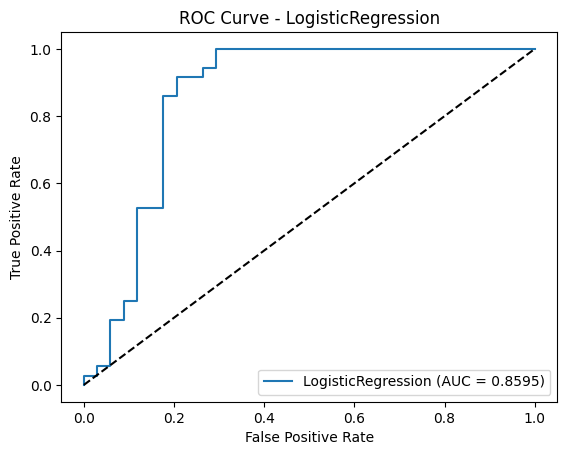


===== RandomForest =====
Training Accuracy: 1.0000
Testing Accuracy: 0.9143
10-Fold CV Accuracy (Full Dataset): 0.8970
Classification Report (Test Set):
               precision    recall  f1-score   support

           0       1.00      0.82      0.90        34
           1       0.86      1.00      0.92        36

    accuracy                           0.91        70
   macro avg       0.93      0.91      0.91        70
weighted avg       0.93      0.91      0.91        70

AUC Score (Test Set): 0.9522


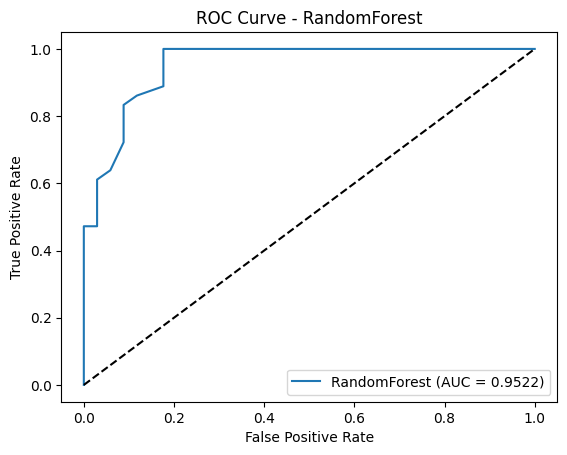


===== SVM =====
Training Accuracy: 0.8710
Testing Accuracy: 0.8286
10-Fold CV Accuracy (Full Dataset): 0.8571
Classification Report (Test Set):
               precision    recall  f1-score   support

           0       0.96      0.68      0.79        34
           1       0.76      0.97      0.85        36

    accuracy                           0.83        70
   macro avg       0.86      0.82      0.82        70
weighted avg       0.86      0.83      0.82        70

AUC Score (Test Set): 0.8946


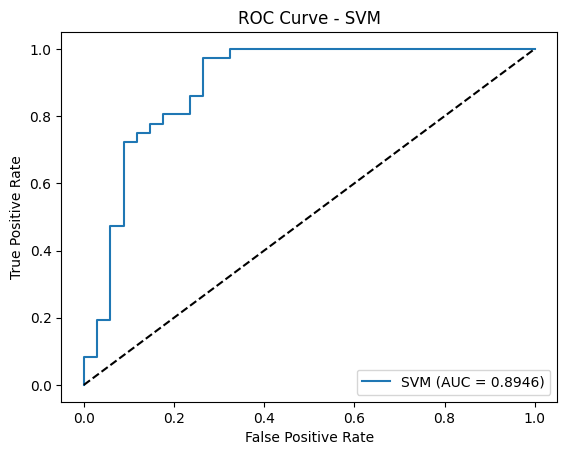

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, accuracy_score
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import numpy as np

# 1️⃣ Loop through each model
for model_name, info in results.items():
    print(f"\n===== {model_name} =====")

    # Extract selected features for this model
    selected_indices = info["Selected Feature Indices"]
    selected_features = X.iloc[:, selected_indices]

    # Train-test split for training/testing evaluation
    X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
        selected_features, y, test_size=0.2,stratify=y
    )

    # Initialize model
    if model_name == "LogisticRegression":
        model = LogisticRegression()
    elif model_name == "RandomForest":
        model = RandomForestClassifier()
    elif model_name == "SVM":
        model = SVC(probability=True)

    # Fit model on train set
    model.fit(X_train_sel, y_train_sel)

    # Predictions
    y_train_pred = model.predict(X_train_sel)
    y_test_pred = model.predict(X_test_sel)

    # Training and Testing Accuracy
    train_acc = accuracy_score(y_train_sel, y_train_pred)
    test_acc = accuracy_score(y_test_sel, y_test_pred)

    print(f"Training Accuracy: {train_acc:.4f}")
    print(f"Testing Accuracy: {test_acc:.4f}")

    # -------------------------------
    # Cross-validation on full dataset
    # -------------------------------
    cv_scores = cross_val_score(model, selected_features, y, cv=10, scoring='accuracy')
    cv_acc = np.mean(cv_scores)
    print(f"10-Fold CV Accuracy (Full Dataset): {cv_acc:.4f}")

    # Classification report (on test set)
    print("Classification Report (Test Set):\n", classification_report(y_test_sel, y_test_pred))

    # ROC Curve and AUC (on test set)
    y_prob = model.predict_proba(X_test_sel)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test_sel, y_prob)
    auc_score = roc_auc_score(y_test_sel, y_prob)
    print(f"AUC Score (Test Set): {auc_score:.4f}")

    # Plot ROC
    plt.figure()
    plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.4f})')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {model_name}")
    plt.legend(loc="lower right")
    plt.show()


Stacking Model Results:
Training Accuracy: 0.9785
Testing Accuracy: 0.8429
k-Fold CV Accuracy (Full Dataset): 0.8886

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.90      0.76      0.83        34
           1       0.80      0.92      0.86        36

    accuracy                           0.84        70
   macro avg       0.85      0.84      0.84        70
weighted avg       0.85      0.84      0.84        70

AUC Score (Test Set): 0.9167


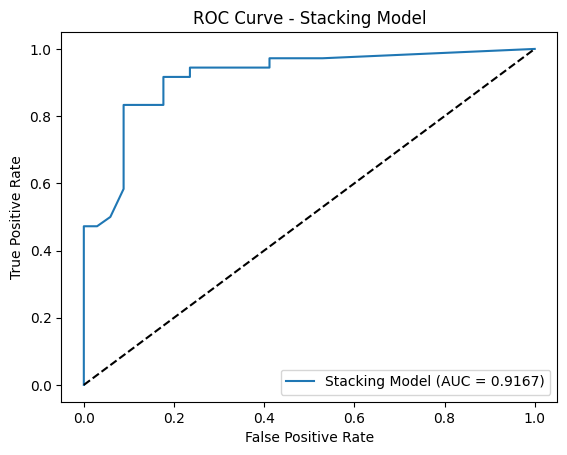

In [ ]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# 1️⃣ Use union of selected features
# -------------------------------
X_selected_union = X[union_features_names]  # union of selected features
y_target = y

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected_union)

# Train-test split for training/testing evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_target, test_size=0.2, stratify=y_target
)

# -------------------------------
# 2️⃣ Define base learners and meta-learner
# -------------------------------
base_learners = [
    ('lr', LogisticRegression()),
    ('svm', SVC(kernel='linear', probability=True)),
    ('rf_base', RandomForestClassifier())
]

meta_learner = RandomForestClassifier()

stack_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,
    passthrough=False
)

# -------------------------------
# 3️⃣ Fit stacking model
# -------------------------------
stack_model.fit(X_train, y_train)

# -------------------------------
# 4️⃣ Predictions and evaluation
# -------------------------------
# Train/Test predictions
y_train_pred = stack_model.predict(X_train)
y_test_pred = stack_model.predict(X_test)

# Training & Testing Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

# Cross-validation accuracy on FULL dataset
cv_scores = cross_val_score(stack_model, X_scaled, y_target, cv=10, scoring='accuracy')
cv_acc = np.mean(cv_scores)

print("Stacking Model Results:")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")
print(f"k-Fold CV Accuracy (Full Dataset): {cv_acc:.4f}")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

# ROC Curve and AUC (Test set)
y_prob = stack_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
print(f"AUC Score (Test Set): {auc_score:.4f}")

# Plot ROC
plt.figure()
plt.plot(fpr, tpr, label=f'Stacking Model (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Stacking Model")
plt.legend(loc="lower right")
plt.show()


Stacking Model Results (Logistic Regression as Meta-Learner):
Training Accuracy: 0.9713
Testing Accuracy: 0.8857
k-Fold CV Accuracy (Full Dataset): 0.8913

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.93      0.82      0.88        34
           1       0.85      0.94      0.89        36

    accuracy                           0.89        70
   macro avg       0.89      0.88      0.88        70
weighted avg       0.89      0.89      0.89        70

AUC Score (Test Set): 0.9526


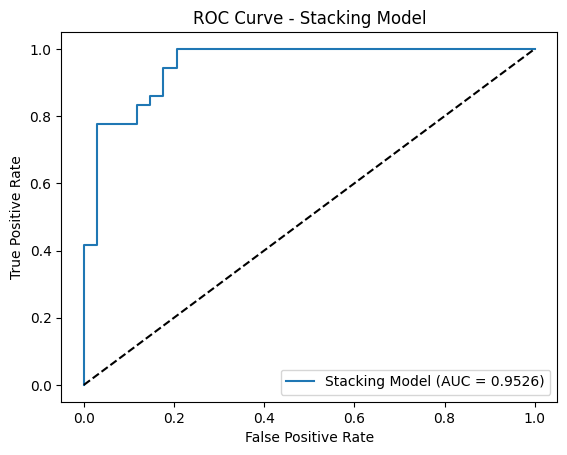

In [ ]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# 1️⃣ Use union of selected features
# -------------------------------
X_selected_union = X[union_features_names]  # union of selected features
y_target = y

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected_union)

# Train-test split for training/testing evaluation
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_target, test_size=0.2, stratify=y_target
)

# -------------------------------
# 2️⃣ Define base learners and meta-learner
# -------------------------------
base_learners = [
    ('lr', LogisticRegression()),
    ('svm', SVC(kernel='linear', probability=True)),
    ('rf_base', RandomForestClassifier())
]

# ✅ Use Logistic Regression as meta-learner
meta_learner = LogisticRegression()

stack_model = StackingClassifier(
    estimators=base_learners,
    final_estimator=meta_learner,
    cv=5,
    passthrough=False
)

# -------------------------------
# 3️⃣ Fit stacking model
# -------------------------------
stack_model.fit(X_train, y_train)

# -------------------------------
# 4️⃣ Predictions and evaluation
# -------------------------------
# Train/Test predictions
y_train_pred = stack_model.predict(X_train)
y_test_pred = stack_model.predict(X_test)

# Training & Testing Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

# Cross-validation accuracy on FULL dataset
cv_scores = cross_val_score(stack_model, X_scaled, y_target, cv=10, scoring='accuracy')
cv_acc = np.mean(cv_scores)

print("Stacking Model Results (Logistic Regression as Meta-Learner):")
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")
print(f"k-Fold CV Accuracy (Full Dataset): {cv_acc:.4f}")
print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_test_pred))

# ROC Curve and AUC (Test set)
y_prob = stack_model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
print(f"AUC Score (Test Set): {auc_score:.4f}")

# Plot ROC
plt.figure()
plt.plot(fpr, tpr, label=f'Stacking Model (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Stacking Model")
plt.legend(loc="lower right")
plt.show()
